In [1]:
from random import random

import numpy as np

import matplotlib.pyplot as plt
import networkx as nx

import matplotlib as mpl
import json
import copy

In [2]:

import sys
import logging
sys.path.append('E:\wangzhilin\QuantumGalaxy')
from QGI.mysql import MYSQL

import pandas as pd
import numpy as np
from QGI.neoapi import Neo4j
from QGI.feishu import *
import os
def get_logger(name,level=None,file=None):
    logger=logging.getLogger(name)
    logger.setLevel(logging.INFO)
    
    ch=logging.StreamHandler()
    ch.setLevel(logging.INFO)
    formatter=logging.Formatter(fmt='%(asctime)s %(name)-12s %(levelname)-8s %(message)s',datefmt='%m-%d %H:%M')
    ch.setFormatter(formatter)
    
    logger.addHandler(ch)
    if file:    
        fh=logging.FileHandler("E:/wangzhilin/QuantumGalaxy/logs/%s.log"%file,'a',encoding='utf-8')
        fh.setLevel(logging.INFO)
        fh.setFormatter(formatter)
        logger.addHandler(fh)
    return logger
logger=get_logger('logger')
uri = "neo4j+ssc://08ef0a79.databases.neo4j.io"
user = "QG_Editor"
password = "editor"
neo=Neo4j(uri,user,password)


In [3]:
import networkx

## 从neo找到骨干节点和边，从mysql找到相关节点的stdchg数据


In [16]:
backbone='煤炭'
cypher='match (n) where n.backbone contains "%s" \
return distinct n.name,labels(n),n.backbone,n.code \
union all \
match (n1) where n1.backbone contains "%s" \
with n1 \
match (n:Indicator)-[]-(n1) \
return  distinct n.name,labels(n),n.backbone,n.code order by labels(n)'%(backbone,backbone)
nodes=neo.read_query(cypher)
cypher='match p=(n1)-[r]->(n2) where n1.backbone contains "%s" and n2.backbone contains "%s" return startNode(r).name,endNode(r).name,type(r) \
union all \
match p=(n:Indicator)-[r]-(n1) where n1.backbone contains "%s"\
return  distinct startNode(r).name,endNode(r).name,type(r)'%(backbone,backbone,backbone)
edges=neo.read_query(cypher)

09-27 12:03 logger       INFO     accept cypher query match (n) where n.backbone contains "煤炭" return distinct n.name,labels(n),n.backbone,n.code union all match (n1) where n1.backbone contains "煤炭" with n1 match (n:Indicator)-[]-(n1) return  distinct n.name,labels(n),n.backbone,n.code order by labels(n)
09-27 12:03 logger       INFO     get 61 records
09-27 12:03 logger       INFO     accept cypher query match p=(n1)-[r]->(n2) where n1.backbone contains "煤炭" and n2.backbone contains "煤炭" return startNode(r).name,endNode(r).name,type(r) union all match p=(n:Indicator)-[r]-(n1) where n1.backbone contains "煤炭"return  distinct startNode(r).name,endNode(r).name,type(r)
09-27 12:03 logger       INFO     get 81 records


In [17]:
host='localhost'
user='Local_Editor'
password='QuantumGalaxy'
database='qgdbs'
mysql=MYSQL(host,user,password,database)

09-27 12:03 logger       INFO     using username Local_Editor
09-27 12:03 logger       INFO     accessed to database <qgdbs>


In [18]:
class QGDiGraph(nx.DiGraph):
    pass


In [19]:
date=mysql.read_query('select date from processed_data where code="000001.SZ" order by date desc limit 1')
std7d=pd.DataFrame(index=[d[0] for d in date])
std1m=pd.DataFrame(index=[d[0] for d in date])
std3m=pd.DataFrame(index=[d[0] for d in date])

for node in nodes:
    code=node[3]
    if code:
        d=mysql.read_query('select date,stdchg7d,stdchg1m,stdchg3m from processed_data where code= "%s" order by date desc limit 30'%code)
        df7d=pd.DataFrame(index=[row[0]for row in d],columns=[code],data=[row[1] for row in d])
        df1m=pd.DataFrame(index=[row[0]for row in d],columns=[code],data=[row[2] for row in d])
        df3m=pd.DataFrame(index=[row[0]for row in d],columns=[code],data=[row[3] for row in d])
        std7d=pd.concat([std7d,df7d],axis=1)
        std1m=pd.concat([std1m,df1m],axis=1)
        std3m=pd.concat([std3m,df3m],axis=1)

09-27 12:03 logger       INFO     got a cursor
09-27 12:03 logger       INFO     Accepted read sql query "select date from processed_data where code="000001.SZ" order by date desc limit 1"
09-27 12:03 logger       INFO     got a cursor
09-27 12:03 logger       INFO     Accepted read sql query "select date,stdchg7d,stdchg1m,stdchg3m from processed_data where code= "600123.SH" order by date desc limit 30"
09-27 12:03 logger       INFO     got a cursor
09-27 12:03 logger       INFO     Accepted read sql query "select date,stdchg7d,stdchg1m,stdchg3m from processed_data where code= "3668.HK" order by date desc limit 30"
09-27 12:03 logger       INFO     got a cursor
09-27 12:03 logger       INFO     Accepted read sql query "select date,stdchg7d,stdchg1m,stdchg3m from processed_data where code= "AMR.N" order by date desc limit 30"
09-27 12:03 logger       INFO     got a cursor
09-27 12:03 logger       INFO     Accepted read sql query "select date,stdchg7d,stdchg1m,stdchg3m from processed_dat

In [20]:
for col,ser in std1m.iteritems():
    for id,data in ser.iteritems():
        if data>2:
            print(id,col,data)
            std1m.loc[id,col]=2
        elif data<-2:
            print(id,col,data)
            std1m.loc[id,col]=-2
    

2022-09-06 3668.HK 2.07409
2022-09-06 600188.SH 2.06028
2022-09-13 601991.SH 2.18359
2022-09-09 601991.SH 2.51702
2022-09-08 601991.SH 2.41333
2022-09-07 601991.SH 2.25021
2022-09-06 601991.SH 2.32402
2022-09-05 601991.SH 2.09541
2022-09-09 600027.SH 2.33351
2022-09-08 600027.SH 2.21402
2022-09-07 600027.SH 2.24417
2022-09-06 600027.SH 2.03843


In [21]:
std7d=std7d.sort_index().fillna(method='bfill').dropna()
std7d.to_csv(r'E:\wangzhilin\QuantumGalaxy\backbone\raw_data\std7d.csv')
std1m=std1m.sort_index().fillna(method='bfill').dropna()
std1m.to_csv(r'E:\wangzhilin\QuantumGalaxy\backbone\raw_data\std1m.csv')
std3m=std3m.sort_index().fillna(method='bfill').dropna()
std3m.to_csv(r'E:\wangzhilin\QuantumGalaxy\backbone\raw_data\std3m.csv')
std1m

,600123.SH,3668.HK,AMR.N,600546.SH,600188.SH,600746.SH,600426.SH,600010.SH,BTU.N,SSL.N,...,VALE.N,600027.SH,600780.SH,000557.SZ,600989.SH,600578.SH,ZC.CZC,JM.DCE,J.DCE,I.DCE
2022-07-29,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.540828,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-01,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.252832,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-02,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.488067,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-05,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.106502,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-08,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.420089,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-09,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.375507,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-10,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,0.142801,-0.039824,...,0.127922,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-11,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,0.328563,0.449430,...,0.312809,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-12,0.135646,-0.096908,0.746568,0.806269,1.091870,0.393870,0.675844,0.279668,0.337244,0.449430,...,0.070676,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-15,0.135646,-0.096908,0.618012,0.806269,1.091870,0.393870,0.675844,0.279668,0.389954,0.605396,...,0.403134,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709


In [22]:
edges[0]

<Record startNode(r).name='合成氨' endNode(r).name='尿素' type(r)='compose'>

## 获得初始graph实例，以及画networkx图轮子

In [23]:
def init_graph():
    G=QGDiGraph()
    assert nx.is_directed_acyclic_graph(G)
    
    for node in nodes:
        G.add_node(node[0],**node[1:])
    for edge in edges:
        G.add_edge(edge[0],edge[1],relationship=edge[2])
    return G
G=init_graph()

In [24]:
for a in nx.ancestors(G,'热力'):
    print(G.nodes[a]['labels(n)'])

['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Product']
['Company', 'Indicator']
['Company', 'Indicator']
['Technique']
['Company', 'Indicator']
['Product']
['Company', 'Indicator']
['Company', 'Indicator']
['Product']
['Company', 'Indicator']
['Company', 'Indicator']
['Product']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Product']
['Indicator']
['Company', 'Indicator']
['Technique']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']


In [25]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码问题

In [26]:
class Backbone_handler():
    def __init__(self,G:nx.Graph):
        self.G=G

    def nodes_group_by_label(self):
        G=self.G
        self.product={}
        self.company={}
        self.technique={}
        self.nodes={'product':self.product,'company':self.company,'technique':self.technique}
        for node,attr in G.nodes(True):
            labels=attr['labels(n)']
            if 'Product' in labels:
                self.product[node]=attr
            elif 'Company' in labels:
                self.company[node]=attr
            elif 'Technique' in labels:
                self.technique[node]=attr
        
    def edges_group_by_rela(self):
        G=self.G
        self.carry=[]
        self.compose=[]
        self.edges={'compose':self.compose,'carry':self.carry}
        for s,e,attr in G.edges(data=True):
            rela=attr['relationship']
            attr['velocity']=random()
            if 'compose' in rela:
                self.compose.append((s,e,attr))
            if 'carry' in rela:
                self.carry.append((s,e,attr))

    def draw_graph(self,frame=0):
        cmap=plt.cm.winter_r
        self.nodes_group_by_label()
        self.edges_group_by_rela()
        #pos=nx.spring_layout(G,k=1/sqrt(len(self.G.nodes)),weight=None,scale=1,seed=20)
        pos=nx.spring_layout(self.G,k=1e4/self.G.number_of_nodes(),scale=1,seed=1,iterations=10000,threshold=1e-15)
        #pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
        #pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
        fig, ax = plt.subplots(dpi=200)
        for label,nodes in self.nodes.items():
            if label=='product':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"o",}
            #print(draw_args)
            elif label=='technique':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"v",}
            nx.draw_networkx_nodes(G, pos=pos,ax=ax, **draw_args)

        # edges
        
        edge_colors=[]
        for rela,edges in self.edges.items():
                
            e = [(u, v) for (u, v, d) in edges ]
            colors=[d['velocity'] for (u, v, d) in edges ]
            draw_args={'width':6,'edge_color':"k",'style':"solid",'alpha':None,'arrowstyle':"-|>",'arrowsize':10,'label':None,'edge_color':colors,'edge_cmap':cmap}
            draw_edges=nx.draw_networkx_edges(G, pos, edgelist=e, ax=ax,**draw_args)
            edge_colors+=colors
        #edge_colors=[d['velocity'] for (u, v, d) in G.edges(data=True) ]
        
        # node labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif",ax=ax)
        # edge weight labels
        edge_labels = nx.get_edge_attributes(G, "velocity")
        edge_labels={k:round(v,2) for k,v in edge_labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels,ax=ax)

        ax = plt.gca()
        ax.margins(0.1)
        plt.axis("off")
        plt.tight_layout()
        pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
        pc.set_array(edge_colors)

        ax = plt.gca()
        ax.set_axis_off()
        plt.colorbar(pc,ax=ax)
        plt.show()
        #return(draw_edges)
    def export_json(self):
        pass


In [27]:
a=Backbone_handler(G)


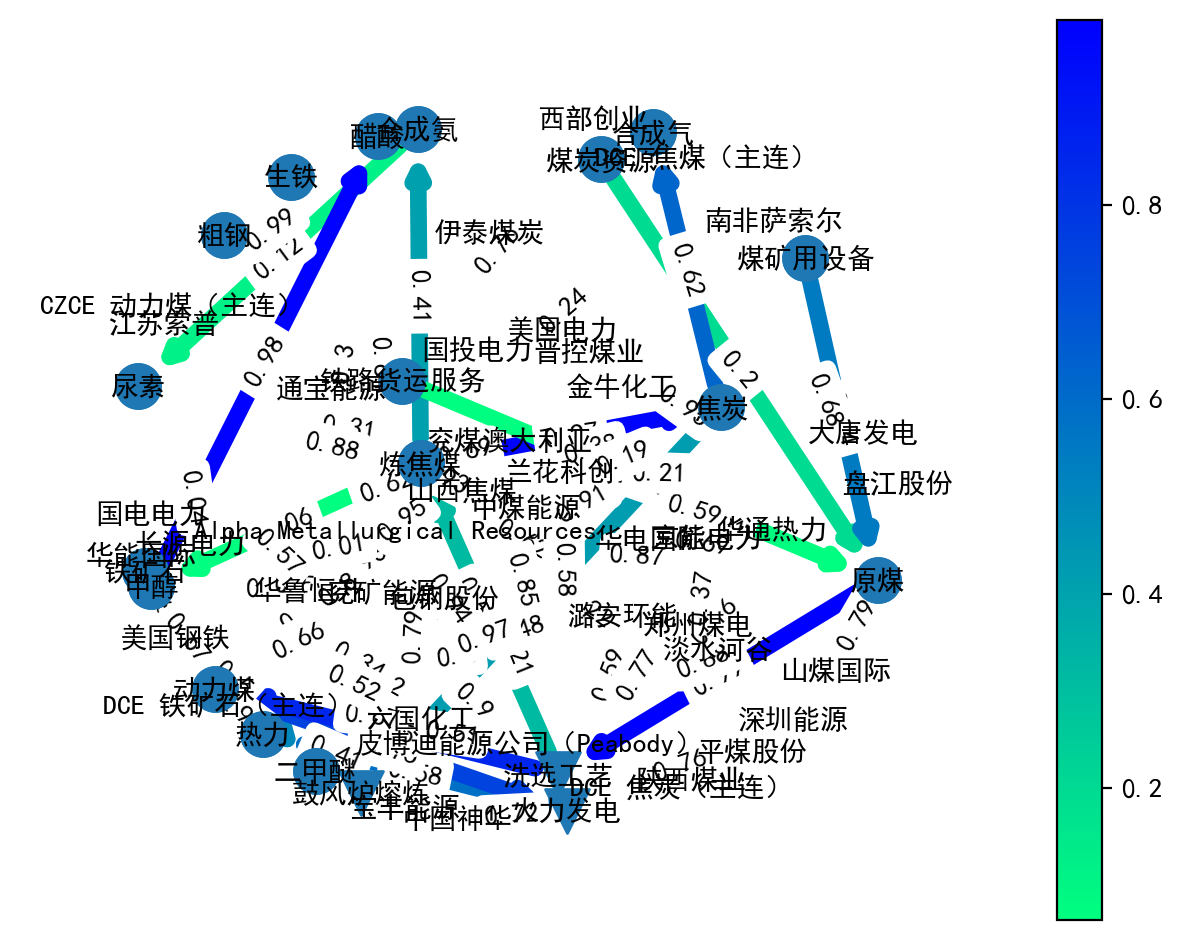

In [28]:

e=a.draw_graph()

In [29]:
G.number_of_nodes()

61

In [30]:
G.__class__

__main__.QGDiGraph

## 影响力传导计算
1. 从所有indicator边传导到对应的产品/工艺的供需差（数据用stdchg1m），在各节点加权平均（权重暂为1，考虑用市值/量利等），得到多个在节点上的初始激励
2. 使用定好的算法计算每个激励在图上的传播，并加和得到节点的供需差和边上的供需差强度变化(ds_current)。（该计算可以通过生成网络的影响力矩阵获得，影响力矩阵是由网络结构得到的网络中任何一个点/边之间的影响力参数）

### step1

In [31]:
raw_data=std1m.iloc[ 0:1,:]
raw_data

,600123.SH,3668.HK,AMR.N,600546.SH,600188.SH,600746.SH,600426.SH,600010.SH,BTU.N,SSL.N,...,VALE.N,600027.SH,600780.SH,000557.SZ,600989.SH,600578.SH,ZC.CZC,JM.DCE,J.DCE,I.DCE
2022-07-29,0.135646,-0.096908,0.781054,0.806269,1.09187,0.39387,0.675844,0.279668,-0.041727,-0.540828,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709


In [45]:
G.successors()

TypeError: successors() missing 1 required positional argument: 'n'

In [49]:
'688083.SH'.lower()

'688083.sh'

In [46]:
G.nodes

NodeView(('合成氨', '甲醇', '二甲醚', '热力', '鼓风炉熔炼', '煤炭资源', '醋酸', '尿素', '火力发电', '动力煤', '煤矿用设备', '粗钢', '焦炭', '炼焦煤', '生铁', '铁矿石', '原煤', '洗选工艺', '合成气', '铁路货运服务', '兰花科创', '兖煤澳大利亚', 'Alpha Metallurgical Resources', '山煤国际', '兖矿能源', '江苏索普', '华鲁恒升', '包钢股份', '皮博迪能源公司（Peabody）', '南非萨索尔', '美国钢铁', '陕西煤业', '长源电力', '潞安环能', '盘江股份', '平煤股份', '山西焦煤', '中国神华', '中煤能源', '晋控煤业', '大唐发电', '深圳能源', '国投电力', '美国电力', '华通热力', '伊泰煤炭', '金牛化工', '六国化工', '郑州煤电', '国电电力', '华能国际', '淡水河谷', '华电国际', '通宝能源', '西部创业', '宝丰能源', '京能电力', 'CZCE 动力煤（主连）', 'DCE 焦煤（主连）', 'DCE 焦炭（主连）', 'DCE 铁矿石（主连）'))

In [37]:
for s  in G.successors('醋酸'):
    print(s)

In [33]:
G=init_graph()

dic={}
for name,attr in G.nodes(True):
    if attr['n.code']:
        dic[attr['n.code']]=name
for date,r in std1m.iterrows():
    G=init_graph()
    #每天为一组数据，放到nodes/edges里
    #print(date)
    datas=r.values
    column=r.index
    for code,data in r.iteritems():
        node=dic[code]
        G.nodes[node]['std']=data
    break

In [34]:
G.nodes.data('i')

NodeDataView({'合成氨': None, '甲醇': None, '二甲醚': None, '热力': None, '鼓风炉熔炼': None, '煤炭资源': None, '醋酸': None, '尿素': None, '火力发电': None, '动力煤': None, '煤矿用设备': None, '粗钢': None, '焦炭': None, '炼焦煤': None, '生铁': None, '铁矿石': None, '原煤': None, '洗选工艺': None, '合成气': None, '铁路货运服务': None, '兰花科创': None, '兖煤澳大利亚': None, 'Alpha Metallurgical Resources': None, '山煤国际': None, '兖矿能源': None, '江苏索普': None, '华鲁恒升': None, '包钢股份': None, '皮博迪能源公司（Peabody）': None, '南非萨索尔': None, '美国钢铁': None, '陕西煤业': None, '长源电力': None, '潞安环能': None, '盘江股份': None, '平煤股份': None, '山西焦煤': None, '中国神华': None, '中煤能源': None, '晋控煤业': None, '大唐发电': None, '深圳能源': None, '国投电力': None, '美国电力': None, '华通热力': None, '伊泰煤炭': None, '金牛化工': None, '六国化工': None, '郑州煤电': None, '国电电力': None, '华能国际': None, '淡水河谷': None, '华电国际': None, '通宝能源': None, '西部创业': None, '宝丰能源': None, '京能电力': None, 'CZCE 动力煤（主连）': None, 'DCE 焦煤（主连）': None, 'DCE 焦炭（主连）': None, 'DCE 铁矿石（主连）': None}, data='i')

In [35]:
for n,preds in G.pred.items():
    if preds:
        values=[]
        for pred in preds:
            std=G.nodes.data('std')[pred]
            
            if std:
                values.append(std)
        if len(values)!=0:
            G.nodes[n]['i']=np.average(values)
[(n,d) for (n,d) in G.nodes.data('i') if d]

[('甲醇', 0.49455709999999997),
 ('二甲醚', 0.135646),
 ('热力', 0.6364295),
 ('醋酸', 0.720528),
 ('尿素', -0.049459866666666664),
 ('火力发电', 0.12993346153846155),
 ('动力煤', 0.34125889166666673),
 ('焦炭', 0.34916010000000003),
 ('炼焦煤', 0.38773552222222224),
 ('铁矿石', 0.42472375),
 ('原煤', 0.20078938750000003),
 ('铁路货运服务', -0.269411)]

### step 2


In [65]:
dir(G)

['__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adj',
 '_node',
 '_pred',
 '_succ',
 'add_edge',
 'add_edges_from',
 'add_node',
 'add_nodes_from',
 'add_weighted_edges_from',
 'adj',
 'adjacency',
 'adjlist_inner_dict_factory',
 'adjlist_outer_dict_factory',
 'clear',
 'clear_edges',
 'copy',
 'degree',
 'edge_attr_dict_factory',
 'edge_subgraph',
 'edges',
 'get_edge_data',
 'graph',
 'graph_attr_dict_factory',
 'has_edge',
 'has_node',
 'has_predecessor',
 'has_successor',
 'in_degree',
 'in_edges',
 'is_directed',
 'is_multigraph',
 'name',
 'nbunch_iter',
 'neighbors',
 'node_attr_dict_f

## 从数据处理成颜色，将每帧数据保存到js文件

In [ ]:
import copy

node_json=[]
for n in copy.deepcopy(G.nodes(data=True)):
    name,attr=n
    attr['name']=name
    attr['labels']=attr.pop('labels(n)')
    node_json.append(attr)
edge_json=[]
for e in copy.deepcopy(G.edges(data=True)):
    s,end,attr=e
    attr['source']=s
    attr['target']=end
    
    edge_json.append(attr)
#node_json=json.dumps(node_json)
#edge_json=json.dumps(edge_json)
data=json.dumps({'nodes':node_json,'links':edge_json,'categories':['Product','Technique','Company','Indicator']},ensure_ascii=False)
data

In [ ]:
nx.is_directed_acyclic_graph(G)

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import cool

In [ ]:
cdict = {'red':   [[0.0,  91/255, 91/255],
                   [0.5,  200/255, 200/255],
                   [1.0,  255/255, 255/255]],
         'green': [[0.0,  218/255, 218/255],
                   [0.5, 200/255, 200/255],
                   [1, 94/255, 94/255]],

         'blue':  [[0.0,  146/255, 146/255],
                   [0.5,  121.5/255, 121.5/255],
                   [1.0,  97/255, 97/255]]}

cdict = {'red':   [[0.0,  121/255, 121/255],
                   
                   [1.0,  241/255, 241/255]],
         'green': [[0.0,  240/255, 240/255],
                   
                   [1, 70/255, 70/255]],

         'blue':  [[0.0,  120/255, 120/255],
                   
                   [1.0,  103/255, 103/255]]}
regrcmp = LinearSegmentedColormap('testCmap', segmentdata=cdict, N=256)
rgba = regrcmp(np.linspace(0, 1, 256))

In [ ]:
from matplotlib.cm import cool
cool

In [ ]:
regrcmp

In [ ]:
datas=[0,1,2,3,4,5,6,7,8,9,10]
def normalize(data,datas):

    return (data-np.min(datas))/(np.max(datas)-np.min(datas))
d=normalize(10,datas)
d

In [ ]:
coolcmp=cool


In [ ]:
def get_cmap_color_str(data,cmap):
    '''从正则后的颜色值，获取指定cmap中的颜色，并转化为echarts需要的“rgba(255,255,255,1)”形式'''
    c=cmap(data)
    colors=(c[0]*255,c[1]*255,c[2]*255,1)
    return(f'rgba{colors}')

In [ ]:
get_cmap_color_str(0.05,cool)

In [ ]:
for n in copy.deepcopy(G.nodes(data=True)):
    n[1]['color']='asdf'
    print(n)

In [ ]:
G.number_of_nodes()

In [ ]:
nodes

In [ ]:
jsdata={}
jsdata['categories']=[{'name':"Product"},{'name':"Technique"}, {'name':"Company"}, {'name':"Indicator"}]
jsdata['dates']=std1m.index.astype(str).tolist()
jsdata['nodes']=[]
jsdata['links']=[]
jsdata

In [118]:


dic={}
for name,attr in G.nodes(True):
    if attr['n.code']:
        dic[attr['n.code']]=name
for date,r in std1m.iterrows():
    G=init_graph()
    #每天为一组数据，放到nodes/edges里
    #print(date)
    datas=r.values
    column=r.index
    for code,data in r.iteritems():
        node=dic[code]
        G.nodes[node]['std']=data

        #nor=normalize(data,datas)
        #colorstr=get_cmap_color_str(nor,regrcmp)
        
        #print(colorstr)
    for u,v,attr in G.edges(data=True):
        if 'Indicator' in  G.nodes[u]['labels(n)'] :
            if 'measure' in attr['relationship'] or 'produce' in attr['relationship']:
                attr['velocity']=G.nodes[u]['std']
                nor=normalize(attr['velocity'],datas)
                colorstr=get_cmap_color_str(nor,regrcmp)
                attr['color']=colorstr
        else:
            attr['velocity']=0
        #a=Backbone_handler(G)


        node_json=[]
        stock=list(nx.get_node_attributes(G,'std').values())
        for n in copy.deepcopy(G.nodes(data=True)):
            name,attr=n
            attr['name']=name
            attr['labels']=attr.pop('labels(n)')
            #attr['color']=get_cmap_color_str(normalize(attr['stock'],stock),regrcmp)
            node_json.append(attr)
            
        edge_json=[]
        velocity=list(nx.get_edge_attributes(G,'velocity').values())

        for e in copy.deepcopy(G.edges(data=True)):
            s,end,attr=e
            attr['source']=s
            attr['target']=end
            #print(attr)
            #attr['color']=get_cmap_color_str(normalize(attr['velocity'],velocity),regrcmp)
            #attr['color']=
            #
            edge_json.append(attr)
        #print(edge_json)
        
    #node_json=json.dumps(node_json)
    #edge_json=json.dumps(edge_json)
    jsdata['nodes'].append(node_json)
    jsdata['links'].append(edge_json)
    
jsdata

{'categories': [{'name': 'Product'},
  {'name': 'Technique'},
  {'name': 'Company'},
  {'name': 'Indicator'}],
 'dates': ['2022-07-22',
  '2022-07-25',
  '2022-07-29',
  '2022-08-01',
  '2022-08-02',
  '2022-08-05',
  '2022-08-08',
  '2022-08-09',
  '2022-08-10',
  '2022-08-11',
  '2022-08-12',
  '2022-08-15',
  '2022-08-16',
  '2022-08-17',
  '2022-08-18',
  '2022-08-19',
  '2022-08-22',
  '2022-08-23',
  '2022-08-24',
  '2022-08-25',
  '2022-08-26',
  '2022-08-29',
  '2022-08-30',
  '2022-08-31',
  '2022-09-01',
  '2022-09-02',
  '2022-09-05',
  '2022-09-06',
  '2022-09-07',
  '2022-09-08',
  '2022-09-09',
  '2022-09-12',
  '2022-09-13',
  '2022-09-14',
  '2022-09-15',
  '2022-09-16',
  '2022-09-19',
  '2022-09-20'],
 'nodes': [[{'n.backbone': "'煤炭', '石油天然气'",
    'n.code': None,
    'name': '合成氨',
    'labels': ['Product']},
   {'n.backbone': "'煤炭'", 'n.code': None, 'name': '甲醇', 'labels': ['Product']},
   {'n.backbone': "'煤炭'",
    'n.code': None,
    'name': '二甲醚',
    'labels': [

In [ ]:
js=json.dumps(jsdata,ensure_ascii=False)
js='graph='+js

file=open(r'E:\wangzhilin\QuantumGalaxy\server\static\full_data.js','w',encoding='UTF-8')
file.write(js)
file.close()

In [ ]:
std1m.index

In [ ]:
'''
data={}
data['categories']=[{'name':"Product"},{'name':"Technique"}, {'name':"Company"}, {'name':"Indicator"}]
data['dates']=std1m.index
data['nodes']=[]
data['links']=[]

for frame in range(100):
    print(frame)
    if frame==0:
        G=init_graph()
        
        num=0
        for u,v in nx.edge_dfs(G):
            d=G.edges[u,v]
            if d['relationship']==['compose','measure']:
                
                G.edges[u,v]['velocity']=np.sin(G.edges[u,v]['angle'])
                
                num+=1
                
            else:
                G.edges[u,v]['velocity']=0
        for n,d in G.nodes(data=True):
            if 'Product' in d['labels(n)']:
                G.nodes[n]['stock']=0
            else:
                G.nodes[n]['stock']=0
    else:
        for u,v,d in G.edges(data=True):
            if d['relationship'] in ['produce','measure']:
                G.edges[u,v]['angle']+=pi/9
                G.edges[u,v]['velocity']=np.sin(G.edges[u,v]['angle'])
            else:
                G.edges[u,v]['velocity']=0
        for n,d in G.nodes(data=True):
            if 'Product' in d['labels(n)']:
                G.nodes[n]['stock']+=0
                G.nodes[n]['stock']%=100
            else:
                G.nodes[n]['stock']=0

    #a=Backbone_handler(G)
    node_json=[]
    stock=list(nx.get_node_attributes(G,'stock').values())
    for n in copy.deepcopy(G.nodes(data=True)):
        name,attr=n
        attr['name']=name
        attr['labels']=attr.pop('labels(n)')
        attr['color']=get_cmap_color_str(normalize(attr['stock'],stock),regrcmp)
        node_json.append(attr)
        
    edge_json=[]
    velocity=list(nx.get_edge_attributes(G,'velocity').values())

    for e in copy.deepcopy(G.edges(data=True)):
        s,end,attr=e
        attr['source']=s
        attr['target']=end
        #print(attr)
        attr['color']=get_cmap_color_str(normalize(attr['velocity'],velocity),regrcmp)
        #attr['color']=
        #
        edge_json.append(attr)
    #node_json=json.dumps(node_json)
    #edge_json=json.dumps(edge_json)
    data['nodes'].append(node_json)
    data['links'].append(edge_json)
    
    
js=json.dumps(data,ensure_ascii=False)
js='data='+js
#按帧数生成frame个nodes和links json对象，每个对象里有当帧的点/边信息

data'''

In [ ]:
i=0
for u,v in nx.edge_dfs(G):
    print(u,v)
    i+=1
i

In [ ]:
G.number_of_edges()

In [ ]:
G.nodes['合成氨']['stock']+=15
G.nodes['合成氨']['stock']

In [ ]:
data['nodes'][0][0]

In [ ]:
for n in data['nodes']:
    print(n[0]['stock'])

In [ ]:

file=open(r'E:\wangzhilin\QuantumGalaxy\server\static\full_data.js','w',encoding='UTF-8')
file.write(js)
file.close()

In [ ]:
for e in copy.deepcopy(G.edges(data=True)):
    s,end,attr=e
    

In [ ]:
values=nx.get_edge_attributes(G,'velocity').values()
list(values)

In [ ]:
(2.27**(64-22))/60/60/24/365*1.65

In [ ]:
(2.27**(64-22))/60/60/24/365